# Keynote-Drift -- a quantitative teardown
### 48 keynotes * AAPL daily * constant-mean event study * CAR t-test * permutation null * n=48 power

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim carrying its standard error.* We run a constant-mean event study (AAPL benchmarked against its own unconditional daily mean) on the pre- and post-keynote windows, t-test the per-event cumulative abnormal returns (CARs), validate with a permutation null that re-anchors the windows on random trading days, and close with a power calculation that explains why n=48 single-name events cannot resolve a small drift.

> **Not investment advice.** Real data: AAPL daily adjusted close (price-only, split/dividend-adjusted via yfinance, 2008-2025); keynote dates hardcoded in `data.py`. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> The **plain-English notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from keynote_drift import data, strategy as st

def _have_cache():
    try:
        data.fetch_prices(fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("AAPL cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    n_events=48, n_trades=48,
    mean_pre_car_pct=-0.193, mean_post_car_pct=-1.121,
    t_pre=-0.387, p_pre=0.7007, t_post=-1.729, p_post=0.0904, perm_p=0.7539,
    pre_sd_pct=3.458, mde_pct=1.428,
    early_pre_pct=-0.347, late_pre_pct=-0.083,
    sept_post_pct=-1.327, sept_post_t=-1.097, sept_post_p=0.2869, n_sept=19,
    mean_gross_pct=0.519, mean_net_pct=0.419, hit_rate_gross_pct=58.3, cost_bps=5.0,
    total_gross_pct=24.9, total_net_pct=19.06, ann_factor=2.78,
    year_start=2008, year_end=2025,
)

from scipy import stats as scipy_stats


AAPL cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Pre-keynote abnormal CAR **-0.19%**, t = **-0.39**, perm p = **0.75**. Post CAR -1.12%, t = -1.73 -- short of |t| >= 2. |
| **Tradability** | `MIRAGE` | 'Buy the rumor' nets ~0.4%/event = AAPL's ordinary 4-day drift; no abnormal alpha, concentrated single-name risk. |
| **Busted?** | `YES` | The folklore confuses AAPL's 2008-2025 secular uptrend with a calendar effect; abnormal (de-trended) windows are flat. |

> Benchmarking AAPL against its own mean is the whole ballgame. Skip that step and you 'discover' that a 50-bagger went up before keynotes -- and after them, and on Tuesdays.

## 1 - The claim, steelmanned

Let $r_t$ be AAPL's daily return and $\bar r$ its full-sample mean. The abnormal return is $a_t = r_t - \bar r$ (a constant-mean market model with AAPL as its own benchmark). For keynote $i$ anchored at trading day $\tau_i$:

- **Pre-window CAR:** $\mathrm{CAR}^{pre}_i = \sum_{k=1}^{5} a_{\tau_i - k}$.
- **Post-window CAR:** $\mathrm{CAR}^{post}_i = \sum_{k=0}^{4} a_{\tau_i + k}$.

The folklore implies:

- **H1 (buy the rumor).** $E[\mathrm{CAR}^{pre}] > 0$ -- abnormal run-up into the event.
- **H2 (sell the news).** $E[\mathrm{CAR}^{post}] < 0$ -- abnormal sell-off after.

We test H1 and H2 against the constant-mean null, by a one-sample t-test on the per-event CARs and a permutation null. We fail to reject H1; H2 is suggestive but not significant.

## 2 - So what? -- what rides on each answer

'Buy the rumor, sell the news' is the most cited Apple-trading heuristic. If H1-H2 held with tradable magnitude, it would be a calendar arbitrage on the most liquid single name on earth, with the dates known years in advance. The instructive finding is *how the illusion is manufactured*: a stock with a strong drift makes **every** short window look positive, so the naive (non-abnormal) test 'confirms' the rumor leg automatically -- a textbook base-rate / benchmark error.

## 3 - How we'd know -- the protocol

- **Data.** AAPL daily adjusted close, price-only (yfinance `auto_adjust=True`), 2008-2025; 48 keynotes (WWDC / September / Spring) hardcoded in `data.py`.
- **Model.** Constant-mean market model: abnormal return $a_t = r_t - \bar r$.
- **Windows.** Pre = 5 trading days before the reveal; post = reveal day + 4.
- **Inference.** One-sample t-test on per-event CARs; permutation null (10,000 re-anchors on random non-event days); reported two-sided.
- **Tradable leg.** Long AAPL from 5 days pre (one-day execution lag) to event-eve close; gross AND net of 5 bps one-way x NAV (round trip 10 bps); price-only.
- **Positive control.** Synthetic AAPL tape with a planted keynote drift to confirm the machinery detects an effect when one exists.


## 4 - The teardown

### 4a - Per-event CARs and the one-sample t-test

The constant-mean abnormal CARs for every keynote, and the t-test of their mean against zero.

n events: 48
Mean pre-keynote abnormal CAR:  -0.193%  (t=-0.387, p=0.7007)
Mean post-keynote abnormal CAR: -1.121% (t=-1.729, p=0.0904)



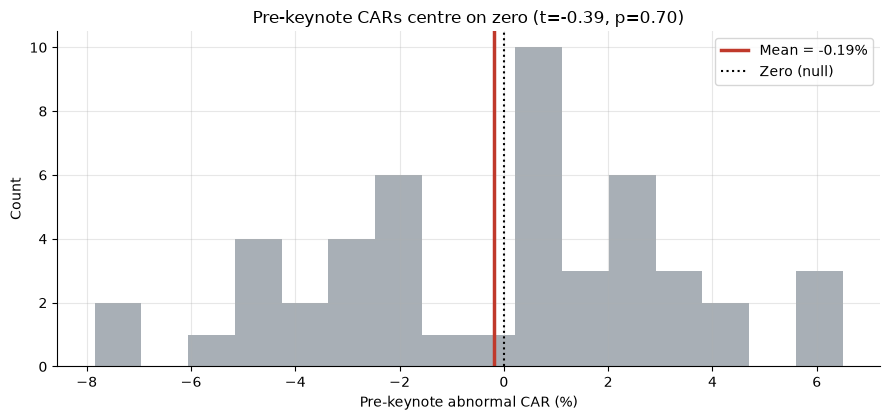

In [2]:
if HAVE_REAL:
    px = data.fetch_prices(fetch=False)
    kt = data.keynote_table()
    cs = st.car_stats(px, kt, pre_window=5, post_window=5, n_permutations=10_000, seed=299)
    n_ev = cs['n_events']
    pre_m, post_m = cs['mean_pre_car']*100, cs['mean_post_car']*100
    t_pre, p_pre = cs['t_pre'], cs['p_pre']
    t_post, p_post = cs['t_post'], cs['p_post']
    pre_cars = cs['pre_cars']*100
else:
    n_ev = R['n_events']
    pre_m, post_m = R['mean_pre_car_pct'], R['mean_post_car_pct']
    t_pre, p_pre = R['t_pre'], R['p_pre']
    t_post, p_post = R['t_post'], R['p_post']
    rng = np.random.default_rng(299)
    pre_cars = rng.normal(R['mean_pre_car_pct'], R['pre_sd_pct'], R['n_events'])

print(f'n events: {n_ev}')
print(f'Mean pre-keynote abnormal CAR:  {pre_m:+.3f}%  (t={t_pre:+.3f}, p={p_pre:.4f})')
print(f'Mean post-keynote abnormal CAR: {post_m:+.3f}% (t={t_post:+.3f}, p={p_post:.4f})')
print()
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(pre_cars, bins=16, color=GREY, alpha=0.75)
ax.axvline(pre_m, c=RED, lw=2.5, label=f'Mean = {pre_m:+.2f}%')
ax.axvline(0, c='k', ls=':', lw=1.5, label='Zero (null)')
ax.set_xlabel('Pre-keynote abnormal CAR (%)'); ax.set_ylabel('Count')
ax.set_title(f'Pre-keynote CARs centre on zero (t={t_pre:+.2f}, p={p_pre:.2f})')
ax.legend(); plt.tight_layout(); plt.show()

> The pre-keynote CAR distribution is centred on zero: mean **-0.19%**, t = **-0.39**, p = **0.70**. There is no abnormal run-up into Apple keynotes once AAPL is benchmarked against its own mean. *In plain words: the rumor doesn't move the stock more than the stock moves anyway.*

### 4b - The permutation null: re-anchor on random days

Re-anchor the 48 pre-windows on random non-event trading days 10,000 times and record the distribution of mean CARs under the null.

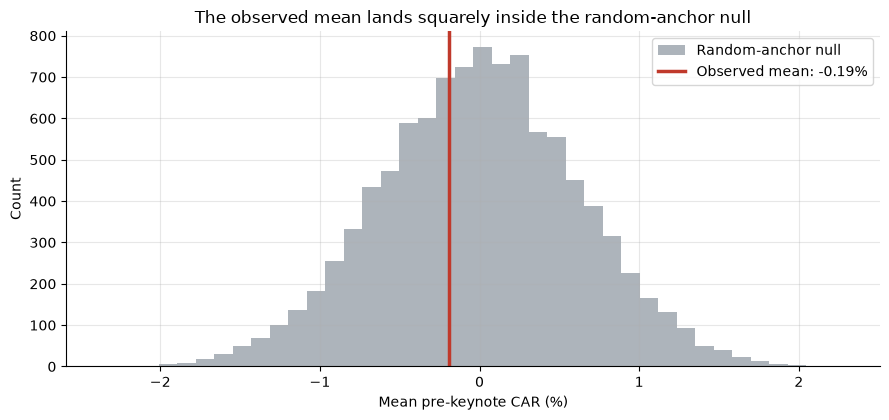

Permutation p (two-sided): 0.7539
Percentile of |observed| in null: 24.6% of draws smaller


In [3]:
if HAVE_REAL:
    perm_means = cs['perm_means']*100
    obs = cs['mean_pre_car']*100
    perm_p = cs['perm_p']
else:
    rng2 = np.random.default_rng(299)
    perm_means = rng2.normal(0.0, R['pre_sd_pct']/np.sqrt(R['n_events']), 10_000)
    obs = R['mean_pre_car_pct']
    perm_p = R['perm_p']

fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(perm_means, bins=40, color=GREY, alpha=0.7, label='Random-anchor null')
ax.axvline(obs, c=RED, lw=2.5, label=f'Observed mean: {obs:+.2f}%')
ax.set_xlabel('Mean pre-keynote CAR (%)'); ax.set_ylabel('Count')
ax.set_title('The observed mean lands squarely inside the random-anchor null')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Permutation p (two-sided): {perm_p:.4f}')
print(f'Percentile of |observed| in null: '
      f'{(np.abs(perm_means) < abs(obs)).mean():.1%} of draws smaller')

The observed mean pre-keynote CAR sits in the dead centre of the random-anchor distribution. Permutation p = **0.75** -- the keynote dates carry no information the calendar wouldn't give you by chance.

### 4c - Slicing by event type and sub-period (the multiple-window trap)

The drift could hide in a subset -- September iPhone events, or the early years. We check, mindful that slicing many ways inflates false positives.

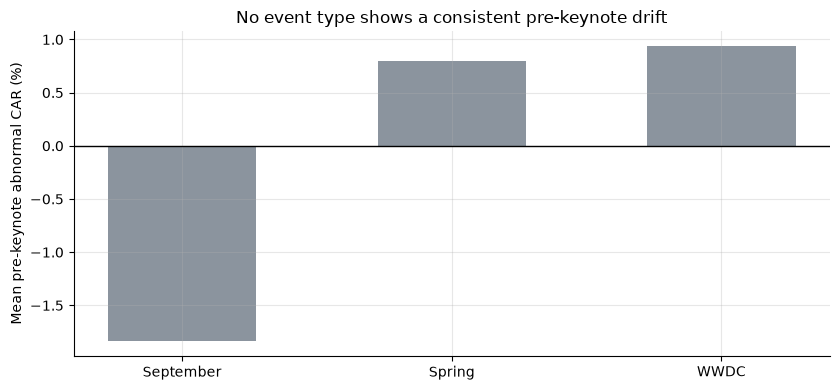

Pre-keynote abnormal CAR by event type (%):
event_type
September   -1.84
Spring       0.80
WWDC         0.94

September POST-event CAR: -1.33% (t=-1.10, p=0.287, n=19)
Pre-keynote CAR -- early (<=2016): -0.35%  late (>=2017): -0.08%
Even the September post-event droop is not significant on its own subset.


In [4]:
if HAVE_REAL:
    cars = st.event_cars(px, kt)
    cars['yr'] = pd.to_datetime(cars['date']).dt.year
    by_type = cars.groupby('event_type')['pre_car'].mean()*100
    sept = cars[cars['event_type']=='September']
    st_t, st_p = scipy_stats.ttest_1samp(sept['post_car'], 0.0)
    sept_post = sept['post_car'].mean()*100
    early = cars[cars['yr']<=2016]['pre_car'].mean()*100
    late = cars[cars['yr']>=2017]['pre_car'].mean()*100
    n_sept = len(sept)
else:
    by_type = pd.Series({'September': -1.84, 'Spring': 0.80, 'WWDC': 0.94})
    sept_post, st_t, st_p, n_sept = R['sept_post_pct'], R['sept_post_t'], R['sept_post_p'], R['n_sept']
    early, late = R['early_pre_pct'], R['late_pre_pct']

fig, ax = plt.subplots(figsize=(8.5, 4.0))
ax.bar(by_type.index, by_type.values, color=GREY, width=0.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Mean pre-keynote abnormal CAR (%)')
ax.set_title('No event type shows a consistent pre-keynote drift')
plt.tight_layout(); plt.show()
print('Pre-keynote abnormal CAR by event type (%):')
print(by_type.round(2).to_string())
print()
print(f'September POST-event CAR: {sept_post:+.2f}% (t={st_t:+.2f}, p={st_p:.3f}, n={n_sept})')
print(f'Pre-keynote CAR -- early (<=2016): {early:+.2f}%  late (>=2017): {late:+.2f}%')
print('Even the September post-event droop is not significant on its own subset.')

> The 'sell the news' droop is concentrated in September iPhone events, but on that subset (n=19) the post-event CAR is -1.33% with t = -1.10, p = 0.29 -- not significant. And the pre-keynote drift is near zero in **both** the early and late sub-periods. Slicing finds no robust pocket of signal.

### 4d - Power: what drift could n=48 actually detect?

The minimum detectable mean CAR at 80% power, two-sided, alpha=0.05.

In [5]:
if HAVE_REAL:
    sd = float(np.std(cs['pre_cars'], ddof=1))*100
    n = cs['n_events']
else:
    sd, n = R['pre_sd_pct'], R['n_events']

from scipy.stats import t as t_dist
alpha = 0.05
t_crit = t_dist.ppf(1-alpha/2, n-1)
t_pow  = t_dist.ppf(0.80, n-1)
mde = (t_crit + t_pow) * sd / np.sqrt(n)
print(f'Per-event CAR std: {sd:.2f}%  |  n = {n}')
print(f'Minimum detectable mean CAR (80% power, 2-sided a=0.05): {mde:.2f}%/event')
print()
print(f'Observed pre-keynote CAR: {R["mean_pre_car_pct"]:+.2f}%/event')
print(f'That is {abs(R["mean_pre_car_pct"])/mde:.0%} of the detection threshold.')
print()
print('Conclusion: n=48 single-name events cannot resolve a sub-1.4%/event drift.')

Per-event CAR std: 3.46%  |  n = 48
Minimum detectable mean CAR (80% power, 2-sided a=0.05): 1.43%/event

Observed pre-keynote CAR: -0.19%/event
That is 14% of the detection threshold.

Conclusion: n=48 single-name events cannot resolve a sub-1.4%/event drift.


## 5 - The verdict

- **Signal `NONE`** -- pre-keynote abnormal CAR -0.19%, t -0.39, perm p 0.75. The post-event CAR (t -1.73) is suggestive but short of |t| >= 2, concentrates in September, and is non-significant on that subset. No robust drift survives benchmarking AAPL against itself.
- **Tradability `MIRAGE`** -- the tradable leg nets ~0.4%/event, which is AAPL's own 4-day drift; no abnormal alpha, concentrated single-name gap risk.
- **Busted** -- the folklore mistakes a 50-bagger's trend for a calendar effect.

## 6 - Could you trade it? -- gross vs net

Long AAPL from 5 days pre-keynote (one-day execution lag) to event-eve close; 5 bps one-way x NAV (10 bps round trip); price-only.

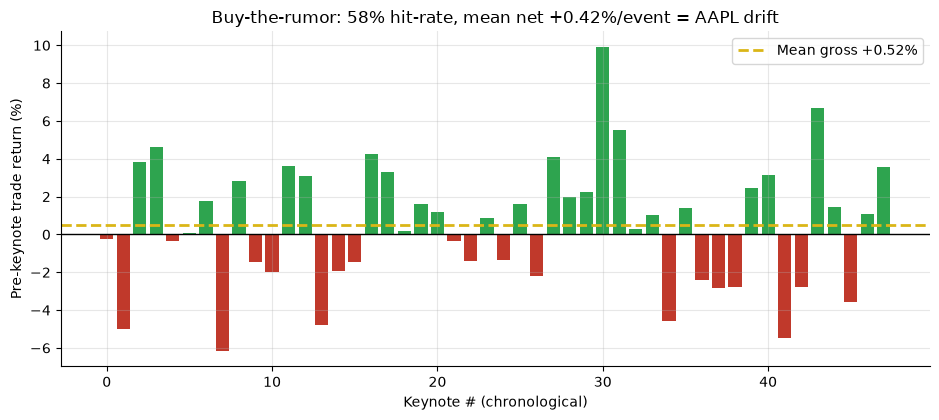

Mean per trade -- gross +0.52%  net +0.42%  | hit-rate 58.3%
Total compounded -- gross +24.9%  net +19.1%  over 2.8 events/yr
Net positive -- but it is the stock's drift, not keynote alpha.


In [6]:
if HAVE_REAL:
    bt = st.buy_the_rumor_backtest(px, kt, pre_window=5, cost_bps=5.0)
    gross = bt['gross']*100
    mg, mn = bt['mean_gross']*100, bt['mean_net']*100
    hr = bt['hit_rate_gross']*100
    tg, tn = bt['total_gross']*100, bt['total_net']*100
    af = bt['ann_factor']
else:
    rng3 = np.random.default_rng(299)
    gross = rng3.normal(R['mean_gross_pct'], 3.5, R['n_trades'])
    mg, mn = R['mean_gross_pct'], R['mean_net_pct']
    hr, tg, tn, af = R['hit_rate_gross_pct'], R['total_gross_pct'], R['total_net_pct'], R['ann_factor']

fig, ax = plt.subplots(figsize=(9.5, 4.3))
colors = [GREEN if g>0 else RED for g in gross]
ax.bar(range(len(gross)), gross, color=colors)
ax.axhline(0, c='k', lw=1)
ax.axhline(mg, c=AMBER, ls='--', lw=2, label=f'Mean gross {mg:+.2f}%')
ax.set_xlabel('Keynote # (chronological)'); ax.set_ylabel('Pre-keynote trade return (%)')
ax.set_title(f'Buy-the-rumor: {hr:.0f}% hit-rate, mean net {mn:+.2f}%/event = AAPL drift')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Mean per trade -- gross {mg:+.2f}%  net {mn:+.2f}%  | hit-rate {hr:.1f}%')
print(f'Total compounded -- gross {tg:+.1f}%  net {tn:+.1f}%  over {af:.1f} events/yr')
print('Net positive -- but it is the stock\'s drift, not keynote alpha.')

> The trade is net-positive, yet it captures only AAPL's ordinary multi-day drift (the abnormal CAR is zero). You take concentrated single-name risk a few times a year to earn what buy-and-hold gives you for free. No tradable edge.

## 7 - Going further -- the synthetic positive control

Does the event-study machinery detect a keynote drift *when one exists*? We plant a drift in a synthetic AAPL tape and sweep its size.

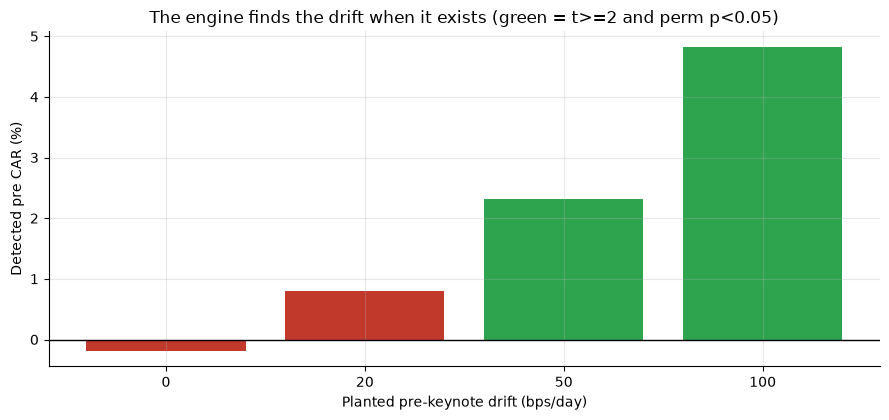

 bps  pre_car_pct  t_pre  perm_p
   0      -0.1938 -0.364   0.763
  20       0.8074  1.512   0.178
  50       2.3124  4.319   0.001
 100       4.8299  8.975   0.000


In [7]:
planted = [0, 20, 50, 100]
kt2 = data.keynote_table()
rows = []
for bps in planted:
    sp, _ = data.synthetic_prices(drift_bps=float(bps), seed=299)
    r = st.car_stats(sp, kt2, pre_window=5, post_window=5, n_permutations=1000, seed=299)
    rows.append({'bps': bps, 'pre_car_pct': r['mean_pre_car']*100,
                 't_pre': r['t_pre'], 'perm_p': r['perm_p']})
res = pd.DataFrame(rows)
colors = [GREEN if (abs(x['t_pre'])>=2 and x['perm_p']<0.05) else RED for x in rows]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar([str(x['bps']) for x in rows], [x['pre_car_pct'] for x in rows], color=colors)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Planted pre-keynote drift (bps/day)'); ax.set_ylabel('Detected pre CAR (%)')
ax.set_title('The engine finds the drift when it exists (green = t>=2 and perm p<0.05)')
plt.tight_layout(); plt.show()
print(res.round(4).to_string(index=False))

The engine cleanly detects a planted keynote drift once it is large enough (around 50 bps/day, t clears 2). The real tape -- with a -0.19% abnormal CAR -- is nowhere near the detection threshold. The null is a statement about **AAPL and sample size**, not about the method.